# Pricing a Variable Annuity Withdrawal Guarantee

Values a 30-year variable annuity with a guaranteed 5% annual withdrawal
from the insurer's side: fee income netted against guarantee shortfalls
and death benefits, simulated under correlated stock and Vasicek rate
dynamics with annual mortality. Risk-neutral pricing is paired with
real-world tail risk, and the base contract is re-priced under a
withdrawal lockup, a different asset mix, and a low-rate start.

| Part | Scenario | Approach |
|---|---|---|
| (a) | Base case value | Seeded 1,000-path Monte Carlo, 90/10 stock and cash mix, year-by-year PV decomposition |
| (b) | Breakeven fee | Root finding on the expected insurer PV |
| (c) | Tail risk | 10% VaR and expected shortfall, risk-neutral and real-world |
| (d) | 5-year withdrawal lockup | Same engine with gated withdrawals |
| (e) | 60/40 allocation | Value and risk against the base mix |
| (f) | Low-rate environment | Initial short rate at 1% instead of 5% |

Contract and market assumptions are documented in the next cell. Paths
are seeded, so results reproduce exactly on rerun.

## Product

- **Term:** 30 years
- **Initial deposit:** $A_0 = \$100$
- **Allocation:** $w_S = 0.9$ (stock), $w_C = 0.1$ (cash), $w_S + w_C = 1$ (no rebalancing)
- **Annual fee:** $f = 2\%$ of grown balance, **taken before the withdrawal** each year
- **Annual withdrawal:** $W = \$5$ fixed dollar (5% of $\$100$ base), starts in year $t_{\text{excl}}+1$
- **Withdrawal exclusion period:** $t_{\text{excl}} = 0$ years base (toggle to $5$ for question (d))
- **Guarantee:** insurer funds the shortfall on the $\$5$ withdrawal whenever the account can't cover it
- **Account balance $A_t$:** customer's balance at end of year $t$; allowed to go negative — that's bookkeeping for the insurer's running paid-out exposure
- **Death benefit:** on death at end of year $T_d$, contract pays $\max\!\big(A_{T_d},\; \text{floor}(T_d)\big)$ where $\text{floor}(t) = \max(0,\; 100 - 5t)$ runs out after 20 years
- **Mortality:** $q = 1\%$ conditional, per year, check at end of each year


#### Market dynamics (risk-neutral, annual steps $\Delta t = 1$)

Indexing convention: $r_t,\, S_t,\, A_t,\, D_t$ are values at time $t$; year-$t$ shocks $Z_{r,t},\, Z_{S,t}$ drive moves over $(t-1,\,t]$.

- **Short rate (Vasicek, Euler-Maruyama):**
$$
dr_t = \kappa(\mu - r_t)\,dt + \sigma_r\,dz_t \quad\Longrightarrow\quad r_{t+1} = r_t + \kappa(\mu - r_t)\,\Delta t + \sigma_r\sqrt{\Delta t}\, Z_{r,t}
$$
  - $\kappa = 0.1,\;\; \mu = 0.03,\;\; \sigma_r = 0.01,\;\; r_0 = 5\%$

- **Stock price (RN GBM):**
$$
d\ln S_t = \big(r_t - \tfrac{1}{2}\sigma_S^2\big)\,dt + \sigma_S\,dW_t \quad\Longleftrightarrow\quad \frac{dS_t}{S_t} = r_t\,dt + \sigma_S\,dW_t
$$
  Annual discretization (year-$t$ stock return uses $r_{t-1}$, the rate at the start of year $t$):
$$
\frac{S_t}{S_{t-1}} = \exp\!\Big(\big(r_{t-1} - \tfrac{1}{2}\sigma_S^2\big)\Delta t + \sigma_S\sqrt{\Delta t}\, Z_{S,t-1}\Big)
$$

- **Stock simple return:**
$$
R_{S,t} = \frac{S_t}{S_{t-1}} - 1
$$
  - $\sigma_S = 20\%$ (implied vol, RN measure)
  - $Z_{S,t} \sim \mathcal{N}(0,1)$, correlated with rate shock by $\rho = 0.10$
  - RW drift 8% and RW vol 15% are not used (would mix measures with stochastic-rate discount)

- **Correlated shocks (Cholesky):**
$$
Z_{S,t} = \rho\, Z_{r,t} + \sqrt{1 - \rho^2}\, Z_{\perp,t}, \qquad Z_{r,t},\, Z_{\perp,t} \stackrel{\text{iid}}{\sim} \mathcal{N}(0,1)
$$

- **Cash leg:** earns $r_{t-1}$ over year $t$ (start-of-year rate, no diffusion)

- **Path-specific discount factor (discrete annual):**
$$
D_t = \prod_{k=0}^{t-1} \frac{1}{1 + r_k}, \qquad D_0 = 1, \qquad D_{t+1} = \frac{D_t}{1 + r_t}
$$
  Each path has its own $D_t$ vector built from its own simulated rate path.


#### Account balance recursion

Year-$t$ flow: market grows the balance, **fee taken on the grown total**, then $\$5$ withdrawal is taken (only if past $t_{\text{excl}}$):
$$
A_t = (1 - f) \cdot \big[\,\underbrace{w_S\, A_{t-1}(1 + R_{S,t})}_{\text{stock leg, grown}} \;+\; \underbrace{w_C\, A_{t-1}(1 + r_{t-1})}_{\text{cash leg, grown}}\,\big] \;-\; W \cdot \mathbb{1}\{t > t_{\text{excl}}\}
$$

$A_t$ is allowed to go negative — that's the insurer's cumulative shortfall ledger.


#### Insurer P&L (per path)

**Per-year cashflows** (only while alive — masking applied at PV stage, see mortality below):

- **Fee in:**
$$
F_t = f \cdot \big[\,w_S\, A_{t-1}(1 + R_{S,t}) \;+\; w_C\, A_{t-1}(1 + r_{t-1})\,\big]
$$

- **Guarantee out** $G_t$ = shortfall when account can't fund the $\$5$ withdrawal (only nonzero for $t > t_{\text{excl}}$):
$$
G_t = \begin{cases} 0 & A_t \geq 0 \\ -A_t & -W \leq A_t < 0 \\ W & A_t < -W \end{cases}
$$


#### Mortality

- $U_t \sim \text{Uniform}(0,1)$ iid for $t = 1, \dots, 30$ (year-$t$ check, end of year)
- $M_0 = 0$; for $t \geq 1$, $M_t = \max\!\big(M_{t-1},\; \mathbb{1}\{U_t < q\}\big)$ — cumulative latched death indicator ("died by end of year $t$")
- **Death year:** $T_d = \min\{t : M_t = 1\}$, set to $\infty$ if no death by year 30
- **Convention — death at end of year $T_d$:** the customer is alive *during* year $T_d$, so year-$T_d$ in-life cashflows $(F_{T_d},\, G_{T_d})$ **are paid**, then at end of year DB is paid. Hence the right "alive during year $t$" mask is $(1 - M_{t-1})$ (alive at start of year $t$).

- **Death benefit cost** (paid once at end of year $T_d$): contract pays $\max(A_{T_d},\, \text{floor}(T_d))$; the account $A_{T_d}$ is the customer's own money, so the insurer only covers the gap:
$$
\text{DB}_{\text{cost}}(T_d) = \max\!\big(0,\; \text{floor}(T_d) - A_{T_d}\big), \qquad \text{floor}(t) = \max(0,\; 100 - 5t)
$$


#### Per-path PV (two ways to treat mortality)

**Option A: path-by-path simulation.** Draw $U_t$, latch $M_t$, mask living cashflows by $(1 - M_{t-1})$ — alive at start of year $t$ — and fire DB cost once on $T_d$:
$$
V_{\text{path}} = \sum_{t=1}^{30} (F_t - G_t)\, D_t \cdot (1 - M_{t-1}) \;-\; \text{DB}_{\text{cost}}(T_d)\, D_{T_d} \cdot \mathbb{1}\{T_d \leq 30\}
$$
Captures path-level interaction (early death + crashed account in same scenario); required for VaR question (c).

**Option B: deterministic mortality weighting (analytical).** Skip the $U_t$ draws; weight each year's living cashflow by $\Pr(\text{alive at start of year } t) = (1-q)^{t-1}$ and each year's DB by $\Pr(\text{died exactly at end of year } t) = (1-q)^{t-1} q$:
$$
V_{\text{path}} = \sum_{t=1}^{30} (1-q)^{t-1}\,(F_t - G_t)\, D_t \;-\; \sum_{t=1}^{30} (1-q)^{t-1}\, q \cdot \text{DB}_{\text{cost}}(t)\, D_t
$$
Same expected value as Option A, lower variance, faster, but only gives the mean — can't answer VaR.


#### Monte Carlo valuation

- **Paths:** $N = 1{,}000$
- **Horizon:** $T = 30$ years, **time step:** $\Delta t = 1$ year
- PV-per-path, then average

**Estimator:**
$$
\hat{V} = \frac{1}{N} \sum_{i=1}^{N} V_{\text{path}}^{(i)}
$$

**Diagnostic breakdown** (split the total into CF splits):

**Option A:**
$$
\overline{\text{PV}_{\text{fees}}} = \tfrac{1}{N}\sum_i \sum_t F_t^{(i)}\, D_t^{(i)} \cdot (1 - M_{t-1}^{(i)})
$$
$$
\overline{\text{PV}_{\text{guar}}} = \tfrac{1}{N}\sum_i \sum_t G_t^{(i)}\, D_t^{(i)} \cdot (1 - M_{t-1}^{(i)})
$$
$$
\overline{\text{PV}_{\text{DB}}} = \tfrac{1}{N}\sum_i \text{DB}_{\text{cost}}(T_d^{(i)})\, D_{T_d}^{(i)} \cdot \mathbb{1}\{T_d^{(i)} \leq 30\}
$$

**Option B:**
$$
\overline{\text{PV}_{\text{fees}}} = \tfrac{1}{N}\sum_i \sum_t (1-q)^{t-1}\, F_t^{(i)}\, D_t^{(i)}
$$
$$
\overline{\text{PV}_{\text{guar}}} = \tfrac{1}{N}\sum_i \sum_t (1-q)^{t-1}\, G_t^{(i)}\, D_t^{(i)}
$$
$$
\overline{\text{PV}_{\text{DB}}} = \tfrac{1}{N}\sum_i \sum_t (1-q)^{t-1}\, q \cdot \text{DB}_{\text{cost}}(t)^{(i)}\, D_t^{(i)}
$$

**Identity:** $\hat{V} = \overline{\text{PV}_{\text{fees}}} - \overline{\text{PV}_{\text{guar}}} - \overline{\text{PV}_{\text{DB}}}$

**Monte Carlo error:**
$$
\text{SE}(\hat{V}) = \frac{\hat{\sigma}_V}{\sqrt{N}}, \qquad \hat{\sigma}_V^2 = \frac{1}{N-1}\sum_{i=1}^{N}\big(V_{\text{path}}^{(i)} - \hat{V}\big)^2
$$


#### Imports:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import brentq

plt.rcdefaults()

### Per-path pipeline

Seven functions, applied in order to one path's year-indexed DataFrame. Steps 1–6 add columns; step 7 collapses the path into a summary dict.

| # | Function | Returns | Needs |
|---|---|---|---|
| 1 | `market_path(seed)` | `r, Z_r, Z_perp, Z_S, R_S` | – |
| 2 | `mortality_path(seed)` | `U, M` | – |
| 3 | `get_account_col(df)` | `A, F, G, S_bucket, C_bucket` | `r, R_S` |
| 4 | `get_disc_fac(df)` | `D` | `r` |
| 5 | `get_alive_dummy(df)` | `alive` | `M` |
| 6 | `get_db_cost_col(df)` | `DB_cost_t` | `A` |
| 7 | `get_path_pv(df)` | → dict (no new cols) | `F, G, D, alive, M, A, DB_cost_t` |

- **`market_path`**: generate Vasicek short rate + correlated stock returns (RN default, RW toggle).
- **`mortality_path`**: annual Uniform$(0,1)$ draws thresholded at $q$, with latched death indicator $M_t$.
- **`get_account_col`**: two-bucket dynamics, no rebalancing, account floored at 0; produces fee $F_t$ and guarantee outflow $G_t$.
- **`get_disc_fac`**: path-specific discrete discount: $D_t = D_{t-1}/(1+r_{t-1})$.
- **`get_alive_dummy`**: $\text{alive}_t = 1 - M_{t-1}$ (death-at-end-of-year convention).
- **`get_db_cost_col`**: hypothetical DB at every year: $\max(0,\text{floor}(t) - A_t)$, $\text{floor}(t)=\max(0,\,100-5t)$.
- **`get_path_pv`**: collapses the path into a dict: $T_d$, $A_{T_d}$, $\text{DB}_{\text{cost}}$, the three PV components, and the final value $V_{\text{path}} = \text{PV}_{\text{fees}} - \text{PV}_{\text{guar}} - \text{PV}_{\text{DB}}$.

In [2]:
def market_path(T=30, dt=1, seed=42, r0=0.05, kappa=0.1, mu=0.03, sigma_r=0.01, sigma_S=0.2, rho=0.1,
                  is_real_world=False, rw_drift=0.08, rw_vol=0.15):
    rng = np.random.default_rng(seed)
    sqrt_dt = np.sqrt(dt)

    Z_r = rng.standard_normal(T)
    Z_perp = rng.standard_normal(T)
    Z_S = rho * Z_r + np.sqrt(1 - rho**2) * Z_perp

    # Vasicek rate path
    r = np.empty(T + 1)
    r[0] = r0
    for t in range(T):
        r[t+1] = r[t] + kappa * (mu - r[t]) * dt + sigma_r * sqrt_dt * Z_r[t]

    if is_real_world:
        # RW stock path
        drift_S = (rw_drift - 0.5 * rw_vol**2) * dt
        R_S = np.exp(drift_S + rw_vol * sqrt_dt * Z_S) - 1
    else:
        # RN stock path
        drift_S = (r[:T] - 0.5 * sigma_S**2) * dt
        R_S = np.exp(drift_S + sigma_S * sqrt_dt * Z_S) - 1

    nan = [np.nan]
    df = pd.DataFrame({
        "r": r,
        "Z_r": np.concatenate([nan, Z_r]),
        "Z_perp": np.concatenate([nan, Z_perp]),
        "Z_S": np.concatenate([nan, Z_S]),
        "R_S": np.concatenate([nan, R_S]),
    })
    df.index = pd.RangeIndex(0, T+1, name="year")
    return df

def mortality_path(T=30, q=0.01, seed=42):
    rng = np.random.default_rng(seed)
    U = rng.uniform(size=T)
    M = np.zeros(T + 1, dtype=int)
    for t in range(1, T + 1):
        M[t] = 1 if (M[t-1] == 1 or U[t-1] < q) else 0

    df = pd.DataFrame({ "U": np.concatenate([[np.nan], U]), "M": M})
    df.index = pd.RangeIndex(0, T+1, name="year")
    return df

def get_account_col(df, f=0.02, S0=90, C0=10, W=5, t_excl=0):
    df = df.copy()
    T = df.index.max()
    r_arr = df["r"].values
    R_S_arr = df["R_S"].values

    S = np.zeros(T + 1); S[0] = S0
    C = np.zeros(T + 1); C[0] = C0
    A = np.zeros(T + 1); A[0] = S0 + C0
    F = np.zeros(T + 1)
    G = np.zeros(T + 1)

    for t in range(1, T + 1):
        S_grown = S[t-1] * (1 + R_S_arr[t])
        C_grown = C[t-1] * (1 + r_arr[t-1])
        gross = S_grown + C_grown

        F[t] = f * gross
        wd = W if t > t_excl else 0
        net = gross - F[t] - wd

        G[t] = max(0, -net)
        A[t] = max(net, 0)

        if gross > 0:
            S[t] = A[t] * S_grown / gross
            C[t] = A[t] * C_grown / gross

    df["A"] = A
    df["F"] = F
    df["G"] = G
    df["S_bucket"] = S
    df["C_bucket"] = C
    return df

def get_disc_fac(df):
    df = df.copy()
    T = df.index.max()
    r_arr = df["r"].values
    D = np.zeros(T + 1); D[0] = 1
    for t in range(1, T + 1):
        D[t] = D[t-1] / (1 + r_arr[t-1])
    df["D"] = D
    return df

def get_alive_dummy(df):
    df = df.copy()
    df["alive"] = 1 - df["M"].shift(1).fillna(0).astype(int)
    return df

def get_db_cost_col(df):
    df = df.copy()
    years = df.index.values
    floor_t = np.maximum(0, 100 - 5 * years)
    df["DB_cost_t"] = np.maximum(0, floor_t - df["A"].values)
    return df

def get_path_pv(df):
    M = df["M"].values

    if M.any():
        T_d = int(np.argmax(M))
        A_at_death = df["A"].iloc[T_d]
        D_at_death = df["D"].iloc[T_d]
        DB_cost = df["DB_cost_t"].iloc[T_d]
        PV_DB = DB_cost * D_at_death
    else:
        T_d = np.nan
        A_at_death = np.nan
        D_at_death = np.nan
        DB_cost = 0
        PV_DB = 0

    PV_fees = (df["F"] * df["D"] * df["alive"]).sum()
    PV_guar = (df["G"] * df["D"] * df["alive"]).sum()
    V_path = PV_fees - PV_guar - PV_DB
    report = {
        "T_d": T_d,
        "A_at_death": A_at_death,
        "D_at_death": D_at_death,
        "DB_cost": DB_cost,
        "PV_fees": PV_fees,
        "PV_guar": PV_guar,
        "PV_DB": PV_DB,
        "V_path": V_path,
    }
    return report

### (a) Base Case Valuation, initial 90%/10% mix and no rebalancing

Run the full Monte Carlo: 1000 paths, 30 years, with base parameters.


Simulated Paths


,T_d,PV_fees,PV_guar,PV_DB,V_path
path,,,,,
0,NaN,27.9011,0.0000,0.0000,27.9011
1,NaN,29.4233,6.7795,0.0000,22.6438
2,17.0,31.0785,0.0000,0.0000,31.0785
3,NaN,12.4373,40.5492,0.0000,-28.1120
4,1.0,1.8283,0.0000,5.6490,-3.8207
...,...,...,...,...,...
995,NaN,13.5433,23.6641,0.0000,-10.1208
996,19.0,13.3020,2.5733,2.1069,8.6219
997,NaN,6.0271,57.0268,0.0000,-50.9997



Valuation results 


,"Base case: 1000 sims, T=30"
Mean PV(fees),22.1753
Mean PV(guarantee),16.4377
Mean PV(DB cost),1.1285
V_mean (insurer PV),4.6091
MC standard error,1.0009
95% CI low,2.6475
95% CI high,6.5708


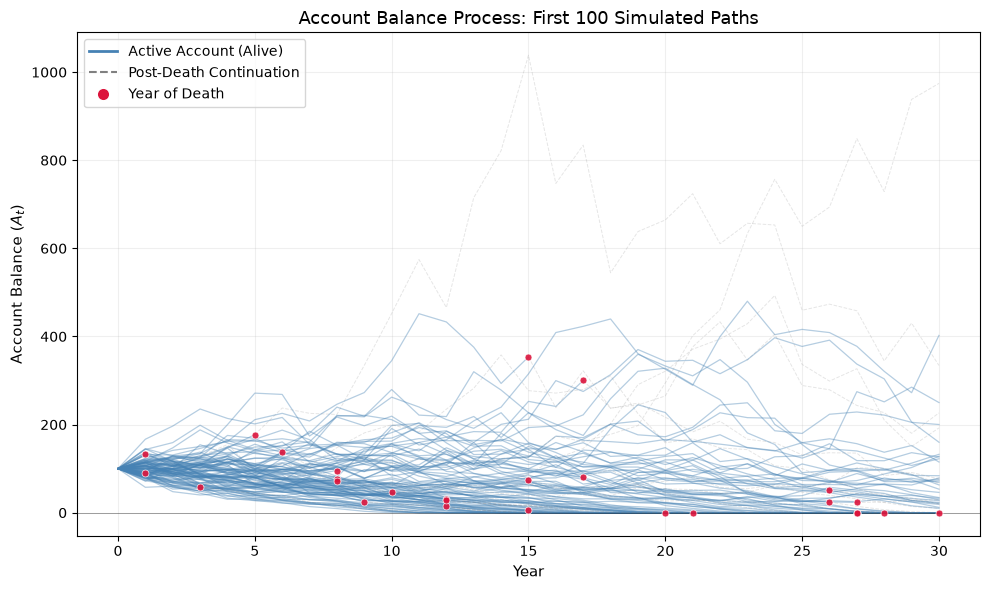

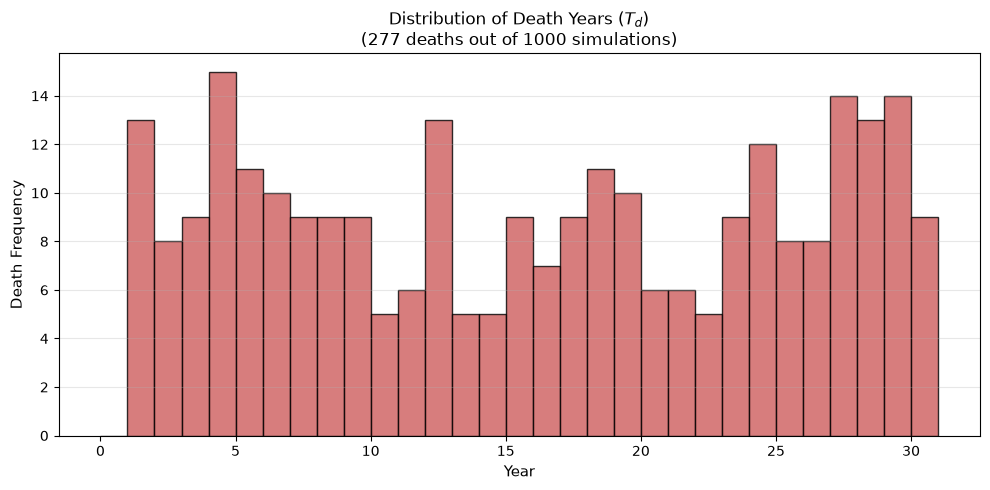

In [3]:
N = 1000
T = 30
sim_paths   = []
path_report = []

for s in range(N):
    df = market_path(seed=s, T=T)
    df = df.join(mortality_path(seed=s+N, T=T))
    df = get_account_col(df)
    df = get_disc_fac(df)
    df = get_alive_dummy(df)
    df = get_db_cost_col(df)

    sim_paths.append(df)
    path_report.append(get_path_pv(df))

sim_paths = pd.concat(sim_paths, keys=range(N), names=["path", "year"])
path_report = pd.DataFrame(path_report, index=pd.RangeIndex(0, N, name="path"))

mean_PV_fees = path_report["PV_fees"].mean()
mean_PV_guar = path_report["PV_guar"].mean()
mean_PV_DB = path_report["PV_DB"].mean()
V_mean = path_report["V_path"].mean()
SE = path_report["V_path"].std() / np.sqrt(N)
CI_low = V_mean - 1.96 * SE
CI_high = V_mean + 1.96 * SE

results_df = pd.DataFrame(
    [mean_PV_fees, mean_PV_guar, mean_PV_DB, V_mean, SE, CI_low, CI_high],
    index=["Mean PV(fees)", "Mean PV(guarantee)", "Mean PV(DB cost)",
           "V_mean (insurer PV)", "MC standard error", "95% CI low", "95% CI high"],
    columns=[f"Base case: {N} sims, T={T}"]
).round(4)

print('Simulated Paths')
display(path_report[["T_d", "PV_fees", "PV_guar", "PV_DB", "V_path"]].round(4))

print('\nValuation results ')
display(results_df)

plt.rcdefaults()
n_plot = 100
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_plot):
    A = sim_paths.loc[i, "A"].values
    T_d = path_report.loc[i, "T_d"]
    if pd.notna(T_d):
        T_d = int(T_d)
        ax.plot(range(T_d + 1), A[:T_d + 1], color="steelblue", alpha=0.4, lw=0.9)
        ax.plot(range(T_d, T + 1), A[T_d:], color="gray", alpha=0.2, lw=0.7, linestyle='--')
        ax.scatter(T_d, A[T_d], color="crimson", s=25, zorder=5, alpha=0.9, edgecolors='white', linewidth=0.5)
    else:
        ax.plot(range(T + 1), A, color="steelblue", alpha=0.4, lw=0.9)
ax.axhline(0, color="black", linestyle="-", lw=0.6, alpha=0.4)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Account Balance ($A_t$)", fontsize=11)
ax.set_title(f"Account Balance Process: First {n_plot} Simulated Paths", fontsize=13)
ax.grid(True, alpha=0.2)
legend_elements = [
    Line2D([0],[0], color='steelblue', lw=2, label='Active Account (Alive)'),
    Line2D([0],[0], color='gray', lw=1.5, linestyle='--', label='Post-Death Continuation'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson', markersize=9, label='Year of Death')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
death_years = path_report["T_d"].dropna()
plt.hist(death_years, bins=range(0, T + 2), color="indianred", edgecolor="black", alpha=0.8)
n_deaths = len(death_years)
pct_death = (n_deaths / N) * 100
plt.title(f"Distribution of Death Years ($T_d$)\n({n_deaths} deaths out of {N} simulations)", fontsize=12)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Death Frequency", fontsize=11)
plt.xticks(range(0, T + 1, 5))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Per-year expected PV contributions

Decompose the insurer's value into year-by-year cashflows. For each year $t$ and each path:

- $\mathrm{PV\,fee}_t = F_t \cdot D_t \cdot \mathrm{alive}_t$
- $\mathrm{PV\,guar}_t = G_t \cdot D_t \cdot \mathrm{alive}_t$
- $\mathrm{PV\,DB}_t = \mathrm{DB}_{\mathrm{cost}} \cdot D_t$ (only at the path's death year)
- $\Delta V_t = \mathrm{PV\,fee}_t - \mathrm{PV\,guar}_t - \mathrm{PV\,DB}_t$

Averaging across the 1000 paths gives the **expected per-year PV contribution**. Summing across years recovers $\hat V = \mathbb{E}[V_{\mathrm{path}}]$.



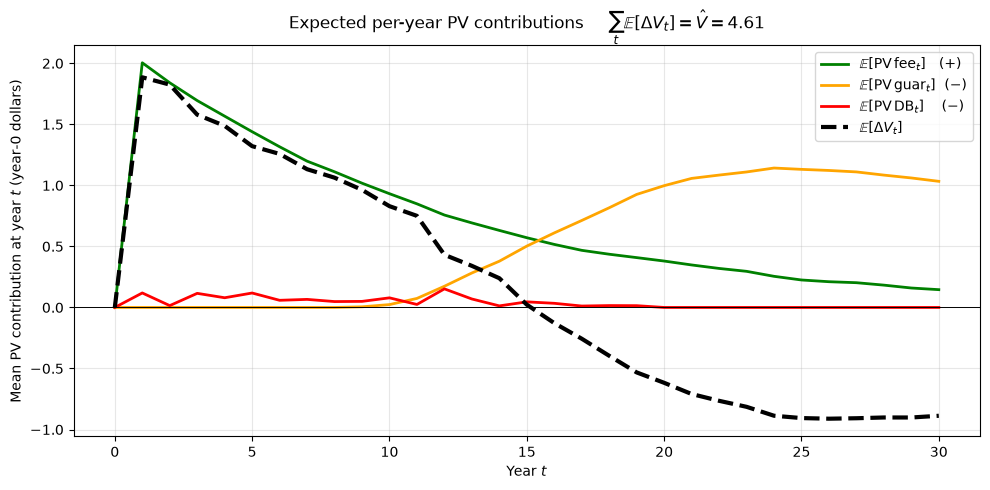

In [4]:
sim_paths["is_death_year"] = sim_paths.groupby(level="path")["M"].diff().fillna(0).astype(int)
sim_paths["PV_Fee_t"] = sim_paths["F"] * sim_paths["D"] * sim_paths["alive"]
sim_paths["PV_Guar_t"] = sim_paths["G"] * sim_paths["D"] * sim_paths["alive"]
sim_paths["PV_DB_t"] = sim_paths["DB_cost_t"] * sim_paths["D"] * sim_paths["is_death_year"]
sim_paths["V_t"] = sim_paths["PV_Fee_t"] - sim_paths["PV_Guar_t"] - sim_paths["PV_DB_t"]
timeline = sim_paths.groupby("year")[["PV_Fee_t", "PV_Guar_t", "PV_DB_t", "V_t"]].mean()

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timeline.index, timeline["PV_Fee_t"], color="green", lw=2,label=r"$\mathbb{E}[\mathrm{PV\,fee}_t]$   $(+)$")
ax.plot(timeline.index, timeline["PV_Guar_t"],color="orange",lw=2,label=r"$\mathbb{E}[\mathrm{PV\,guar}_t]$  $(-)$")
ax.plot(timeline.index, timeline["PV_DB_t"], color="red", lw=2, label=r"$\mathbb{E}[\mathrm{PV\,DB}_t]$    $(-)$")
ax.plot(timeline.index, timeline["V_t"], color="black", lw=3, ls="--", label=r"$\mathbb{E}[\Delta V_t]$")
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("Year $t$")
ax.set_ylabel("Mean PV contribution at year $t$ (year-0 dollars)")
ax.set_title(rf"Expected per-year PV contributions   $\;\;\sum_t \mathbb{{E}}[\Delta V_t] = \hat V = {timeline['V_t'].sum():.2f}$")
ax.legend(loc="upper right", frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### (b) Breakeven Fee

 Find the fee rate $f^\star$ at which the insurer's expected PV is zero.

**Setup.** For path $i$ with fee $f$:
$\quad V^{(i)}(f) \;=\; \text{PV}_{\text{fees}}^{(i)}(f) \;-\; \text{PV}_{\text{guar}}^{(i)}(f) \;-\; \text{PV}_{\text{DB}}^{(i)}(f)$

Monte Carlo estimator:
$\quad \hat V(f) \;=\; \frac{1}{N}\sum_{i=1}^N V^{(i)}(f)$

Breakeven condition:

$$\hat V(f^\star) \;=\; 0$$

All three PV components depend on $f$ — directly through $F_t = f \cdot A_{t-1}^{\text{gross}}$, and indirectly through the account recursion (higher $f$ drains the account faster, firing guarantees sooner and shrinking $A_{T_d}$).

**Method.** Find root numerical  via `scipy.optimize.brentq` on $\hat V(f)$.


Breakeven annual fee (f*) : 1.2590%
Verification: Expected Value at f* = 0.000000


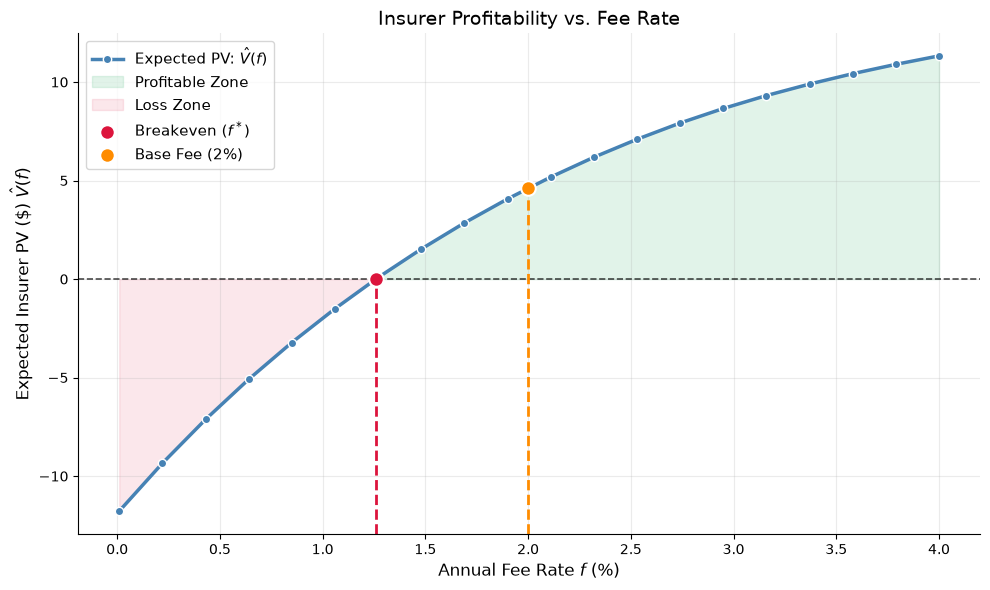

In [5]:
fixed_scenarios = []
for i in range(N):
    df_env = sim_paths.loc[i][["r", "R_S", "M"]].copy()
    fixed_scenarios.append(df_env)

def objective_function(test_f):
    path_values = []
    for df_base in fixed_scenarios:
        df = get_account_col(df_base, f=test_f)
        df = get_disc_fac(df)
        df = get_alive_dummy(df)
        df = get_db_cost_col(df)
        res = get_path_pv(df)
        path_values.append(res["V_path"])
    return np.mean(path_values)

f_star = brentq(objective_function, a=0, b=0.02)
check_val = objective_function(f_star)

print(f"Breakeven annual fee (f*) : {f_star:.4%}")
print(f"Verification: Expected Value at f* = {check_val:.6f}")

f_grid = np.linspace(1e-4, 0.04, 20)
V_at_f = [objective_function(f) for f in f_grid]

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(f_grid * 100, V_at_f, color="steelblue", lw=2.5, marker="o", ms=6, markeredgecolor="white", label=r"Expected PV: $\hat{V}(f)$")
ax.axhline(0, color="black", lw=1.2, ls="--", alpha=0.7)
V_arr = np.array(V_at_f)
ax.fill_between(f_grid * 100, V_arr, 0, where=(V_arr >= 0), color="mediumseagreen", alpha=0.15, label="Profitable Zone", interpolate=True)
ax.fill_between(f_grid * 100, V_arr, 0, where=(V_arr <= 0), color="crimson", alpha=0.10, label="Loss Zone", interpolate=True)
y_bottom, y_top = ax.get_ylim()

ax.vlines(f_star * 100, ymin=y_bottom, ymax=0, color="crimson", ls="--", lw=2)
ax.scatter([f_star * 100], [0], color="crimson", s=110, zorder=5, edgecolor="white", lw=1.5, label="Breakeven ($f^*$)")
ax.vlines(2.0, ymin=y_bottom, ymax=V_mean, color="darkorange", ls="--", lw=2)
ax.scatter([2.0], [V_mean], color="darkorange", s=110, zorder=5, edgecolor="white", lw=1.5, label="Base Fee (2%)")
ax.set_ylim(y_bottom, y_top)

ax.set_xlabel("Annual Fee Rate $f$ (%)", fontsize=12)
ax.set_ylabel(r"Expected Insurer PV (\$) $\hat{V}(f)$", fontsize=12)
ax.set_title("Insurer Profitability vs. Fee Rate", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc="upper left", fontsize=11)
ax.grid(alpha=0.25, linestyle='-')

plt.tight_layout()
plt.show()

### (c) 10% VaR and Expected Shortfall

For per-path insurer PV $V_{\text{path}}$:

$$\text{VaR}_{10\%} \;=\; q_{0.10}\!\left(V_{\text{path}}\right)$$

$$\text{ES}_{10\%} \;=\; \mathbb{E}\!\left[V_{\text{path}} \,\big|\, V_{\text{path}} \le \text{VaR}_{10\%}\right]$$

**Measure.** Real-world for stocks (drift $\mu_{\text{RW}}=0.08$, vol $\sigma_{\text{RW}}=0.15$); rate process and discounting unchanged from part (a). RN reported as sensitivity.


(c) Answer:  VaR_10% = -2.1695


,Risk-Neutral,Real-World
Mean V,4.6091,36.5654
10% VaR,-33.3166,-2.1695
10% ES,-44.8292,-14.1176


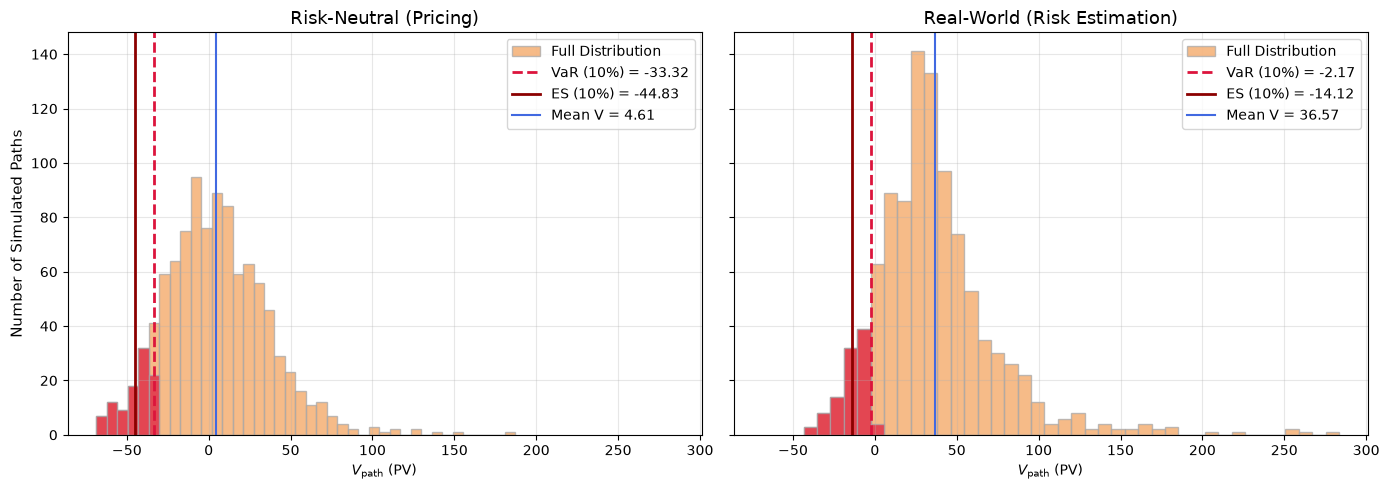

In [6]:
V_RN = path_report["V_path"]
VaR_10_RN = V_RN.quantile(0.10)
ES_10_RN = V_RN[V_RN <= VaR_10_RN].mean()

rw_report = []
for s in range(N):
    df = market_path(seed=s, T=T, is_real_world=True)
    df = df.join(mortality_path(seed=s+N, T=T))
    df = get_account_col(df)
    df = get_disc_fac(df)
    df = get_alive_dummy(df)
    df = get_db_cost_col(df)
    rw_report.append(get_path_pv(df))

rw_report = pd.DataFrame(rw_report, index=pd.RangeIndex(0, N, name="path"))

V_RW = rw_report["V_path"]
VaR_10_RW = V_RW.quantile(0.1)
ES_10_RW = V_RW[V_RW <= VaR_10_RW].mean()
results_c = pd.DataFrame({"Risk-Neutral": [V_RN.mean(), VaR_10_RN, ES_10_RN],
                          "Real-World":   [V_RW.mean(), VaR_10_RW, ES_10_RW],
}, index=["Mean V", "10% VaR", "10% ES"]).round(4)

print(f"(c) Answer:  VaR_10% = {VaR_10_RW:.4f}")
display(results_c)

plt.rcdefaults()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, V, label, var, es in [(axes[0], V_RN, "Risk-Neutral (Pricing)", VaR_10_RN, ES_10_RN),
                              (axes[1], V_RW, "Real-World (Risk Estimation)", VaR_10_RW, ES_10_RW)]:
    bins_edges = np.histogram_bin_edges(V, bins=40)
    ax.hist(V, bins=bins_edges, color="#F4A460", edgecolor="darkgray", alpha=0.75, label="Full Distribution")
    ax.hist(V[V <= var], bins=bins_edges, color="crimson", edgecolor="darkgray", alpha=0.7)
    ax.axvline(var, color="crimson", ls="--", lw=2, label=f"VaR (10%) = {var:.2f}")
    ax.axvline(es, color="darkred", ls="-", lw=2, label=f"ES (10%) = {es:.2f}")
    ax.axvline(V.mean(), color="royalblue", ls="-", lw=1.5, label=f"Mean V = {V.mean():.2f}")   # ← new
    ax.set_title(label, fontsize=13)
    ax.set_xlabel(r"$V_{\mathrm{path}}$ (PV)")
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of Simulated Paths", fontsize=11)
plt.tight_layout()
plt.show()

### (d) 5-Year Withdrawal Lockup

**Adjustment from part (a):** withdrawal $W_t$ is gated by a 5-year exclusion period:

$$W_t \;=\; \begin{cases} 0 & t \le 5 \\ 5 & t > 5 \end{cases}$$

**Value Estimation:**:
$\hat V \;=\; \frac{1}{N}\sum_{i=1}^{N} V^{(i)} $ with $t_{\text{excl}} = 5$ and all other parameters same.


(d) Answer: V = 18.4402


,"5-year lockup: 1000 sims, T=30"
Mean PV(fees),29.5072
Mean PV(guarantee),10.5912
Mean PV(DB cost),0.4757
V_mean (insurer PV),18.4402
MC standard error,1.0386
95% CI low,16.4045
95% CI high,20.4759


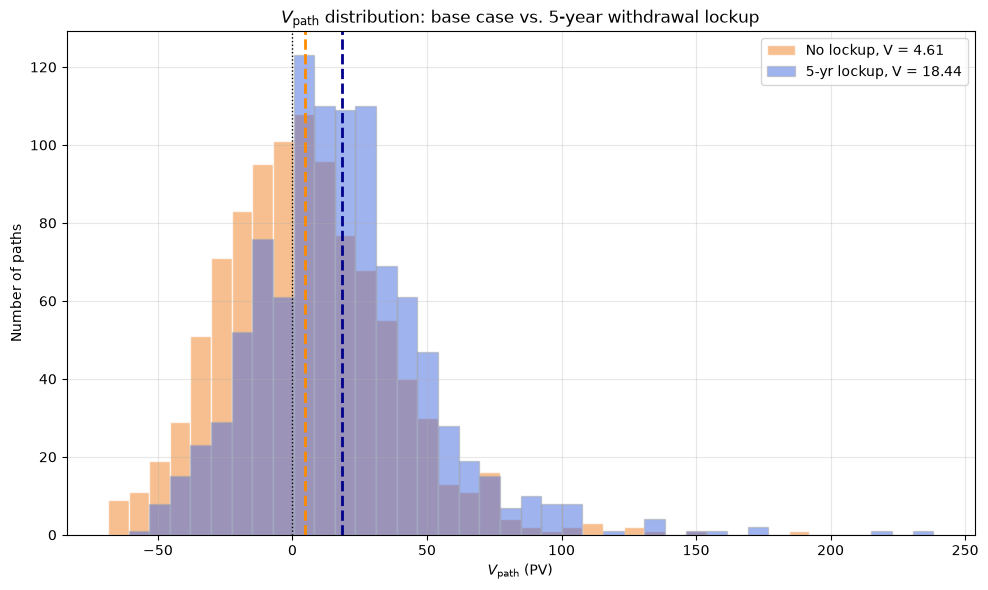

In [7]:
report_d = []
for s in range(N):
    df = market_path(seed=s, T=T)
    df = df.join(mortality_path(seed=s+N, T=T))
    df = get_account_col(df, t_excl=5)
    df = get_disc_fac(df)
    df = get_alive_dummy(df)
    df = get_db_cost_col(df)
    report_d.append(get_path_pv(df))

report_d = pd.DataFrame(report_d, index=pd.RangeIndex(0, N, name="path"))

V_d  = report_d["V_path"].mean()
SE_d = report_d["V_path"].std() / np.sqrt(N)

results_d = pd.DataFrame([report_d["PV_fees"].mean(), report_d["PV_guar"].mean(), report_d["PV_DB"].mean(),
                          V_d, SE_d, V_d - 1.96*SE_d, V_d + 1.96*SE_d],
                         index=["Mean PV(fees)", "Mean PV(guarantee)", "Mean PV(DB cost)", "V_mean (insurer PV)", "MC standard error", "95% CI low", "95% CI high"],
                         columns=[f"5-year lockup: {N} sims, T={T}"]
).round(4)
print(f"(d) Answer: V = {V_d:.4f}")
display(results_d)

V_a = path_report["V_path"]
V_d_series = report_d["V_path"]
bins = np.histogram_bin_edges(np.concatenate([V_a, V_d_series]), bins=40)

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(V_a, bins=bins, color="#F4A460",  alpha=0.7, edgecolor="white", label=f"No lockup, V = {V_a.mean():.2f}")
ax.hist(V_d_series, bins=bins, color="royalblue", alpha=0.5, edgecolor="darkgray", label=f"5-yr lockup, V = {V_d:.2f}")
ax.axvline(V_a.mean(), color="darkorange", lw=2, ls="--")
ax.axvline(V_d, color="darkblue",   lw=2, ls="--")
ax.axvline(0, color="black",lw=1, ls=":")
ax.set_xlabel(r"$V_{\mathrm{path}}$ (PV)")
ax.set_ylabel("Number of paths")
ax.set_title("$V_{\\mathrm{path}}$ distribution: base case vs. 5-year withdrawal lockup")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### (e) 60/40 Stock/Cash Allocation

**Adjustment:** initial allocation change to 60/40 ($S_0 = 60, C_0 = 40$)



(e) Answer: V = 7.7523


,"60/40 mix: 1000 sims, T=30"
Mean PV(fees),21.2174
Mean PV(guarantee),12.8591
Mean PV(DB cost),0.6060
V_mean (insurer PV),7.7523
MC standard error,0.7426
95% CI low,6.2969
95% CI high,9.2077



Change from 90/10 mix:  ΔV = +3.1431


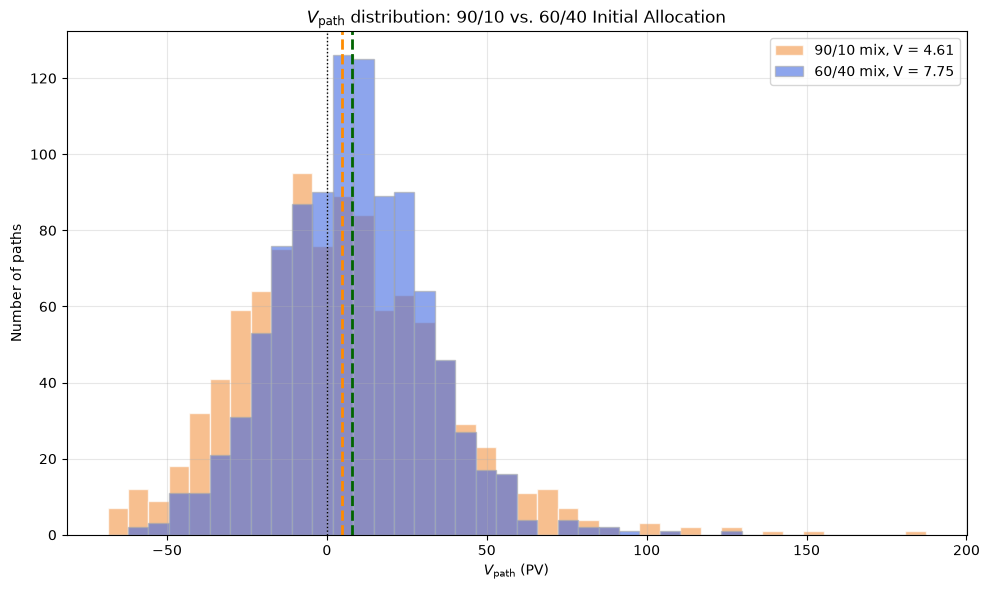

In [8]:
report_e = []
for s in range(N):
    df = market_path(seed=s, T=T)
    df = df.join(mortality_path(seed=s+N, T=T))
    df = get_account_col(df, S0=60, C0=40)
    df = get_disc_fac(df)
    df = get_alive_dummy(df)
    df = get_db_cost_col(df)
    report_e.append(get_path_pv(df))

report_e = pd.DataFrame(report_e, index=pd.RangeIndex(0, N, name="path"))

V_e = report_e["V_path"].mean()
SE_e = report_e["V_path"].std() / np.sqrt(N)

results_e = pd.DataFrame([report_e["PV_fees"].mean(), report_e["PV_guar"].mean(), report_e["PV_DB"].mean(),V_e, SE_e, V_e -
                          1.96*SE_e, V_e + 1.96*SE_e],
                         index=["Mean PV(fees)", "Mean PV(guarantee)", "Mean PV(DB cost)", "V_mean (insurer PV)", "MC standard error", "95% CI low", "95% CI high"],
                         columns=[f"60/40 mix: {N} sims, T={T}"]).round(4)
print(f"(e) Answer: V = {V_e:.4f}")
display(results_e)
print(f"\nChange from 90/10 mix:  ΔV = {V_e - V_mean:+.4f}")

V_a = path_report["V_path"]
V_e_series = report_e["V_path"]
bins = np.histogram_bin_edges(np.concatenate([V_a, V_e_series]), bins=40)

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(V_a, bins=bins, color="#F4A460", alpha=0.7, edgecolor="white", label=f"90/10 mix, V = {V_a.mean():.2f}")
ax.hist(V_e_series, bins=bins, color="royalblue", alpha=0.6, edgecolor="darkgray", label=f"60/40 mix, V = {V_e:.2f}")
ax.axvline(V_a.mean(), color="darkorange", lw=2, ls="--")
ax.axvline(V_e, color="darkgreen", lw=2, ls="--")
ax.axvline(0, color="black", lw=1, ls=":")
ax.set_xlabel(r"$V_{\mathrm{path}}$ (PV)")
ax.set_ylabel("Number of paths")
ax.set_title("$V_{\\mathrm{path}}$ distribution: 90/10 vs. 60/40 Initial Allocation")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Part (e) Real-World Risk Analysis:


,90/10 Base Case (RW),60/40 Mix (RW)
Mean Expected Profit,36.5654,29.6999
10% VaR,-2.1695,2.6441
10% ES,-14.1176,-6.9233


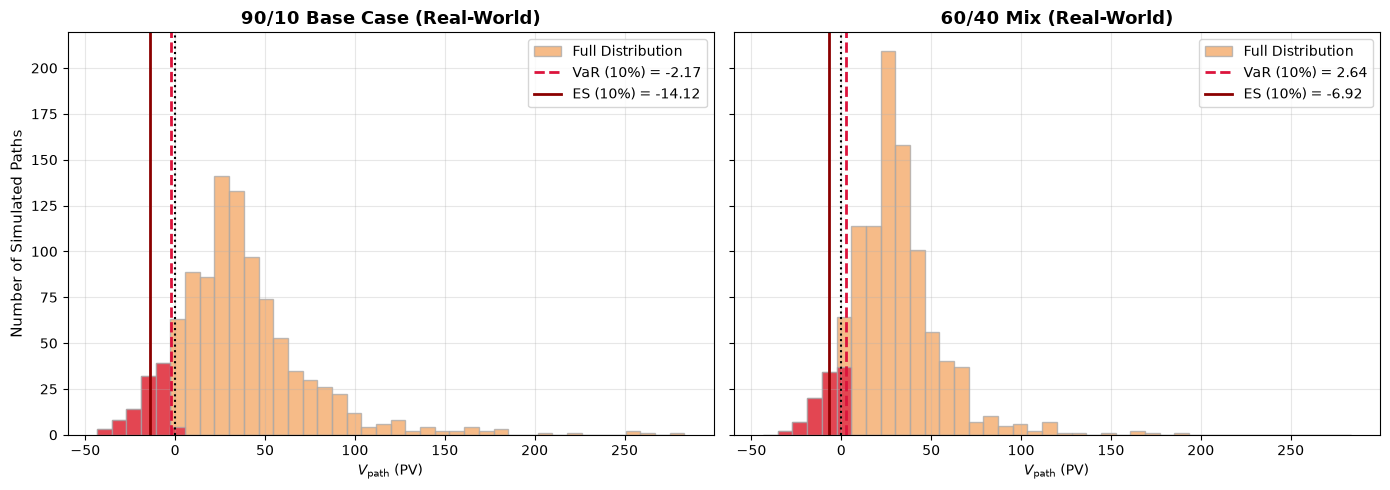

In [9]:
rw_report_e = []
for s in range(N):
    df = market_path(seed=s, T=T, is_real_world=True)
    df = df.join(mortality_path(seed=s+N, T=T))
    df = get_account_col(df, S0=60, C0=40)
    df = get_disc_fac(df)
    df = get_alive_dummy(df)
    df = get_db_cost_col(df)
    rw_report_e.append(get_path_pv(df))

rw_report_e = pd.DataFrame(rw_report_e, index=pd.RangeIndex(0, N, name="path"))
V_RW_e = rw_report_e["V_path"]
VaR_10_RW_e = V_RW_e.quantile(0.10)
ES_10_RW_e  = V_RW_e[V_RW_e <= VaR_10_RW_e].mean()

results_risk_e = pd.DataFrame(
    {"90/10 Base Case (RW)": [V_RW.mean(), VaR_10_RW, ES_10_RW],
     "60/40 Mix (RW)":       [V_RW_e.mean(), VaR_10_RW_e, ES_10_RW_e]},
    index=["Mean Expected Profit", "10% VaR", "10% ES"]
).round(4)

print("Part (e) Real-World Risk Analysis:")
display(results_risk_e)

bins_edges = np.histogram_bin_edges(np.concatenate([V_RW, V_RW_e]), bins=40)
plt.rcdefaults()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, V, label, var, es in [(axes[0], V_RW,   "90/10 Base Case (Real-World)", VaR_10_RW,   ES_10_RW),
                              (axes[1], V_RW_e, "60/40 Mix (Real-World)",       VaR_10_RW_e, ES_10_RW_e)]:
    ax.hist(V, bins=bins_edges, color="#F4A460", edgecolor="darkgray", alpha=0.75, label="Full Distribution")
    ax.hist(V[V <= var], bins=bins_edges, color="crimson", edgecolor="darkgray", alpha=0.7)
    ax.axvline(var, color="crimson", ls="--", lw=2, label=f"VaR (10%) = {var:.2f}")
    ax.axvline(es,  color="darkred", ls="-",  lw=2, label=f"ES (10%) = {es:.2f}")
    ax.axvline(0,   color="black",   ls=":",  lw=1.5)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel(r"$V_{\mathrm{path}}$ (PV)")
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of Simulated Paths", fontsize=11)
plt.tight_layout()
plt.show()

### (f) Low Initial Interest Rate

**Adjustment from part (a):** initial short rate changes from 5% to 1%:

$$r_0 = 0.01$$

Vasicek dynamics unchanged — the rate starts at 1% and mean-reverts toward $\mu = 0.03$ via $dr = \kappa(\mu - r)\,dt + \sigma_r\,dz$.

**Estimator:** identical to part (a) —

$$\hat V \;=\; \frac{1}{N}\sum_{i=1}^{N} V^{(i)}$$

with `r0=0.01` in `market_path`. All other parameters unchanged.

**Expected behavior:** $\hat V$ should drop substantially, likely turning negative. Three reinforcing channels:

- **Cash bucket grows slower** — at $r_t \approx 1\%$ early on, the cash leg compounds at a tiny rate → account drains faster.
- **RN stock drift is also low** — under risk-neutral pricing, $\mu_S^{\mathbb{Q}} = r_t$, so stocks also grow at ~1% early.
- **Discount factors stay closer to 1** — low rates mean future guarantee outflows are barely discounted, so $\text{PV}_{\text{guar}}$ becomes larger in present-value terms.

All three push $V$ in the same direction (down).

(f) Answer: V = -14.7196


,"r0=1%: 1000 sims, T=30"
Mean PV(fees),19.4274
Mean PV(guarantee),31.9722
Mean PV(DB cost),2.1748
V_mean (insurer PV),-14.7196
MC standard error,1.2085
95% CI low,-17.0882
95% CI high,-12.3510



Change from r0=5%:  ΔV = -19.3287


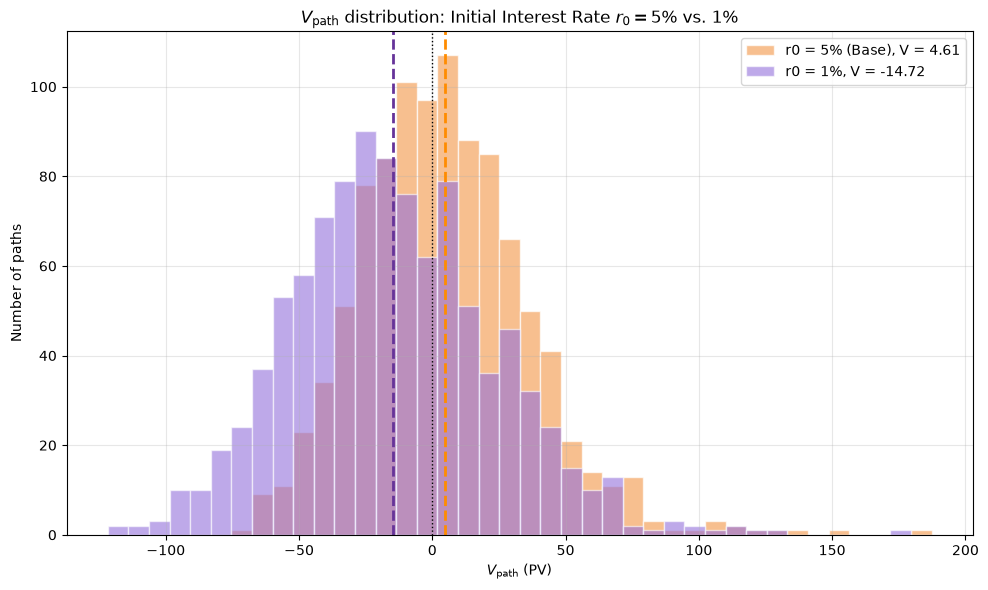

In [10]:
report_f = []
for s in range(N):
    df = market_path(seed=s, T=T, r0=0.01)
    df = df.join(mortality_path(seed=s+N, T=T))
    df = get_account_col(df)
    df = get_disc_fac(df)
    df = get_alive_dummy(df)
    df = get_db_cost_col(df)
    report_f.append(get_path_pv(df))

report_f = pd.DataFrame(report_f, index=pd.RangeIndex(0, N, name="path"))

V_f  = report_f["V_path"].mean()
SE_f = report_f["V_path"].std() / np.sqrt(N)

results_f = pd.DataFrame([report_f["PV_fees"].mean(), report_f["PV_guar"].mean(), report_f["PV_DB"].mean(),V_f, SE_f, V_f -
                          1.96*SE_f, V_f + 1.96*SE_f],
                         index=["Mean PV(fees)", "Mean PV(guarantee)", "Mean PV(DB cost)", "V_mean (insurer PV)", "MC standard error", "95% CI low", "95% CI high"],
                         columns=[f"r0=1%: {N} sims, T={T}"]).round(4)
print(f"(f) Answer: V = {V_f:.4f}")
display(results_f)
print(f"\nChange from r0=5%:  ΔV = {V_f - V_mean:+.4f}")

V_a = path_report["V_path"]
V_f_series = report_f["V_path"]
bins = np.histogram_bin_edges(np.concatenate([V_a, V_f_series]), bins=40)

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(V_a, bins=bins, color="#F4A460", alpha=0.7, edgecolor="white", label=f"r0 = 5% (Base), V = {V_a.mean():.2f}")
ax.hist(V_f_series, bins=bins, color="mediumpurple", alpha=0.6, edgecolor="white", label=f"r0 = 1%, V = {V_f:.2f}")
ax.axvline(V_a.mean(), color="darkorange", lw=2, ls="--")
ax.axvline(V_f, color="rebeccapurple", lw=2, ls="--")
ax.axvline(0, color="black", lw=1, ls=":")
ax.set_xlabel(r"$V_{\mathrm{path}}$ (PV)")
ax.set_ylabel("Number of paths")
ax.set_title("$V_{\\mathrm{path}}$ distribution: Initial Interest Rate $r_0=5\\%$ vs. $1\\%$")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()